Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Capas disponibles:


,name,geometry_type
0,barrios_veredas,MultiPolygon
1,comunas_corregimientos,MultiPolygon
2,limite_medellin,Polygon
3,barrios,MultiPolygon
4,veredas,MultiPolygon
5,comunas,MultiPolygon
6,corregimientos,MultiPolygon


/usr/local/lib/python3.13/dist-packages/geopandas/io/file.py:576: UserWarning: Error parsing datetimes, original strings are returned: Out of bounds nanosecond timestamp: 1675-11-02T00:00:00Z, at position 0. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.
  return pyogrio.read_dataframe(path_or_bytes, bbox=bbox, **kwargs)
/usr/local/lib/python3.13/dist-packages/geopandas/io/file.py:576: UserWarning: Error parsing datetimes, original strings are returned: Out of bounds nanosecond timestamp: 1616-03-02T00:00:00Z, at position 0. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessaril

Ráster reproyectado guardado en: /content/drive/MyDrive/2.Consultoria/01_PAC_MEDELLIN_2026/2.Ejecución/C1_01_EVIDENCIA_DIAGNOSTICO_PROSPECTIVA/P1_Caracterizacion_Socioeconomica_Ambiental/02_DOCUMENTOS_EN_ELABORACION/07_1_CLIMA_RELIEVE/03_DATOS_PREPARADOS/20260910/koppen_geiger_1991_2020_medellin_9377.tif
Códigos Köppen-Geiger presentes: [1, 2, 15]
Capa política: comunas_corregimientos
Número de divisiones: 23
Campo usado para etiquetas: nombre


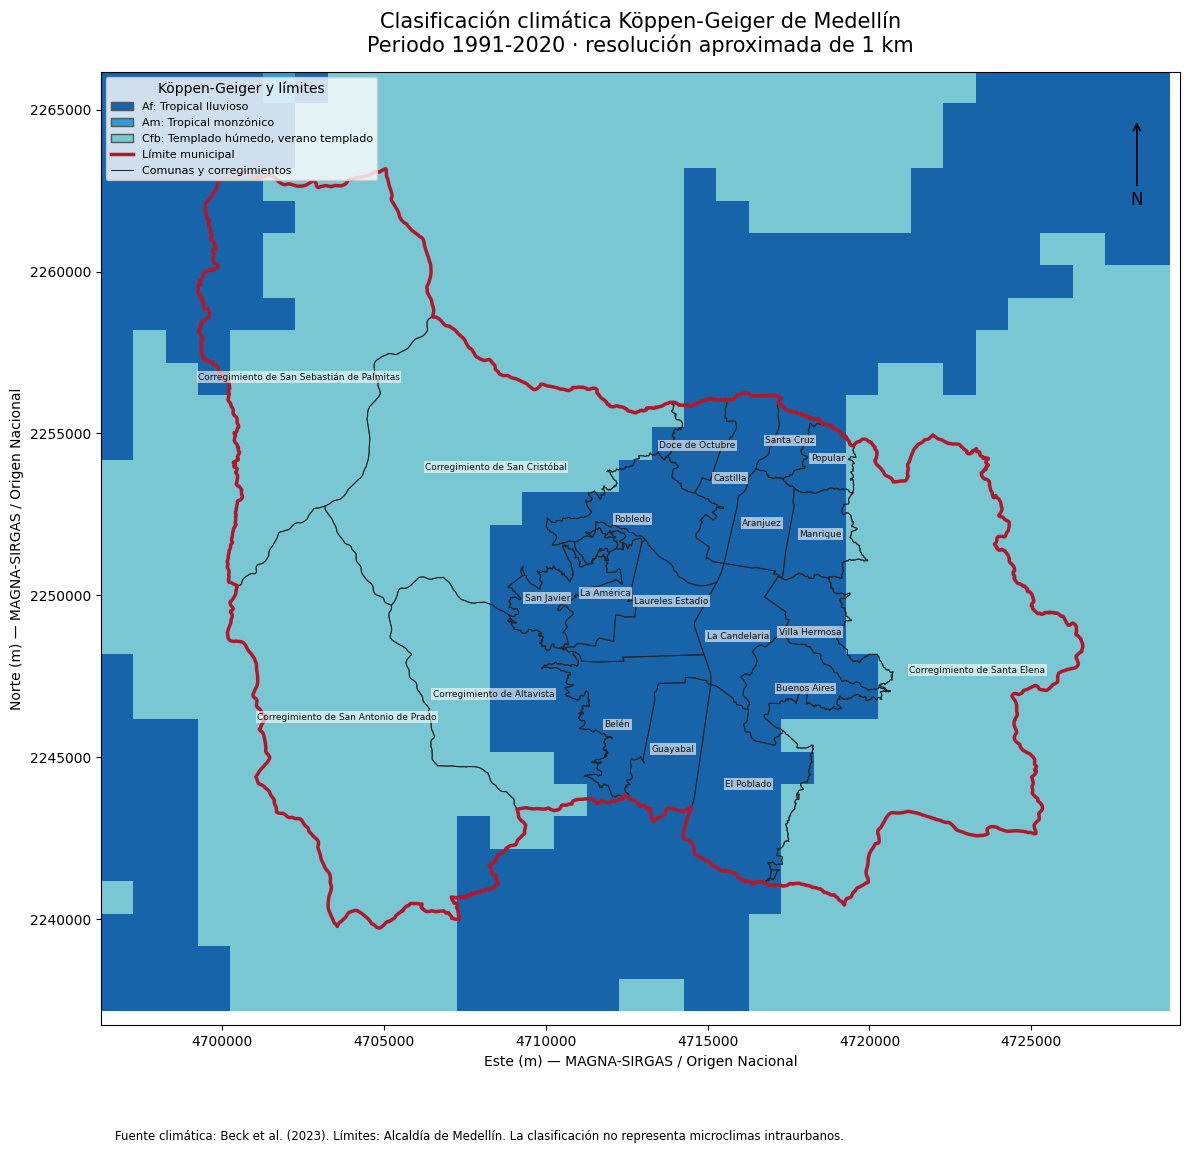

Mapa guardado en:
/content/drive/MyDrive/2.Consultoria/01_PAC_MEDELLIN_2026/2.Ejecución/C1_01_EVIDENCIA_DIAGNOSTICO_PROSPECTIVA/P1_Caracterizacion_Socioeconomica_Ambiental/02_DOCUMENTOS_EN_ELABORACION/07_1_CLIMA_RELIEVE/04_PREVISUALIZACIONES/Koppen_Geiger_1991_2020_Medellin.png


In [5]:
from osgeo import gdal

raster = gdal.OpenEx('/vsicurl/https://data.naturalcapitalalliance.stanford.edu/download/global/koppen_geiger_climatezones/koppen_geiger_climatezones_1991_2020_1km.tif')
band = raster.GetRasterBand(1)

# Define the window variables (example values, adjust as needed)
my_window_x_offset = 0
my_window_y_offset = 0
my_window_width_in_pixels = band.XSize  # Example: read the full width
my_window_height_in_pixels = band.YSize # Example: read the full height

# ============================================================
# KÖPPEN-GEIGER 1991-2020 PARA MEDELLÍN
# Ráster global de 1 km + comunas y corregimientos oficiales
# ============================================================

# Si se ejecuta en Colab:
%pip -q install geopandas pyogrio matplotlib

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

from osgeo import gdal
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

gdal.UseExceptions()

# ------------------------------------------------------------
# 1. RUTAS
# ------------------------------------------------------------

ROOT = Path(
    "/content/drive/MyDrive/2.Consultoria/"
    "01_PAC_MEDELLIN_2026/2.Ejecución/"
    "C1_01_EVIDENCIA_DIAGNOSTICO_PROSPECTIVA/"
    "P1_Caracterizacion_Socioeconomica_Ambiental/"
    "02_DOCUMENTOS_EN_ELABORACION/07_1_CLIMA_RELIEVE"
)

SNAPSHOT = "20260910"

GPKG = (
    ROOT
    / "03_DATOS_PREPARADOS"
    / SNAPSHOT
    / "limites_medellin_9377.gpkg"
)

SALIDA = (
    ROOT
    / "04_PREVISUALIZACIONES"
    / "Koppen_Geiger_1991_2020_Medellin.png"
)

SALIDA.parent.mkdir(
    parents=True,
    exist_ok=True
)

# URL limpia: no debe contener corchetes ni formato Markdown
URL_KOPPEN = (
    "https://data.naturalcapitalalliance.stanford.edu/"
    "download/global/koppen_geiger_climatezones/"
    "koppen_geiger_climatezones_1991_2020_1km.tif"
)

VSI_KOPPEN = f"/vsicurl/{URL_KOPPEN}"

# Escoger la división administrativa que se quiere visualizar
CAPA_DIVISIONES = "comunas_corregimientos"

# True para escribir los nombres sobre el mapa
ETIQUETAR_DIVISIONES = True

# ------------------------------------------------------------
# 2. COMPROBAR ARCHIVOS Y CAPAS
# ------------------------------------------------------------

if not GPKG.exists():
    raise FileNotFoundError(
        f"No se encontró el GeoPackage:\n{GPKG}"
    )

capas_disponibles = gpd.list_layers(GPKG)

print("Capas disponibles:")
display(capas_disponibles)

if CAPA_DIVISIONES not in capas_disponibles["name"].tolist():
    raise ValueError(
        f"No existe la capa '{CAPA_DIVISIONES}'. "
        f"Capas disponibles: "
        f"{capas_disponibles['name'].tolist()}"
    )

# ------------------------------------------------------------
# 3. CARGAR LÍMITES OFICIALES DE MEDELLÍN
# ------------------------------------------------------------

limite = gpd.read_file(
    GPKG,
    layer="limite_medellin"
).to_crs("EPSG:9377")

divisiones = gpd.read_file(
    GPKG,
    layer=CAPA_DIVISIONES
).to_crs("EPSG:9377")

municipio = limite.geometry.union_all()

# Recortar las divisiones al límite municipal
divisiones = gpd.clip(
    divisiones,
    limite
)

if limite.empty:
    raise ValueError(
        "La capa del límite municipal está vacía."
    )

if divisiones.empty:
    raise ValueError(
        "La capa de divisiones quedó vacía después del recorte."
    )

# ------------------------------------------------------------
# 4. RECORTAR Y REPROYECTAR EL RÁSTER REMOTO
# ------------------------------------------------------------

# Se utiliza un margen para que la cuadrícula climática
# sobrepase ligeramente el límite de Medellín.
minx, miny, maxx, maxy = municipio.bounds
MARGEN_M = 3000

bounds_medellin = (
    minx - MARGEN_M,
    miny - MARGEN_M,
    maxx + MARGEN_M,
    maxy + MARGEN_M
)

raster_remoto = gdal.OpenEx(
    VSI_KOPPEN,
    gdal.OF_RASTER
)

if raster_remoto is None:
    raise RuntimeError(
        "GDAL no pudo abrir el ráster remoto de Köppen-Geiger."
    )

# Warp recorta la ventana necesaria y la lleva a EPSG:9377.
# Al ser una clasificación categórica se usa vecino más próximo.
raster_medellin = gdal.Warp(
    "",
    raster_remoto,
    format="MEM",
    dstSRS="EPSG:9377",
    outputBounds=bounds_medellin,
    xRes=1000,
    yRes=1000,
    resampleAlg=gdal.GRA_NearestNeighbour,
    srcNodata=0,
    dstNodata=0,
    multithread=True
)

if raster_medellin is None:
    raise RuntimeError(
        "No fue posible recortar o reproyectar el ráster."
    )

band = raster_medellin.GetRasterBand(1)
array = band.ReadAsArray().astype("float32")

geotransform = raster_medellin.GetGeoTransform()

# ------------------------------------------------------------
# 4.1. GUARDAR RÁSTER REPROYECTADO TEMPORALMENTE
# ------------------------------------------------------------
# Esto permite que otros notebooks o celdas lo utilicen directamente.
RUTA_RASTER_INTERMEDIO = (
    ROOT
    / "03_DATOS_PREPARADOS"
    / SNAPSHOT
    / "koppen_geiger_1991_2020_medellin_9377.tif" # Name needs to contain 'koppen' and '9377'
)

RUTA_RASTER_INTERMEDIO.parent.mkdir(parents=True, exist_ok=True)

gdal.Translate(
    str(RUTA_RASTER_INTERMEDIO),
    raster_medellin,
    format="GTiff",
    noData=0 # Explicitly set NoData value for output
)

print(f"Ráster reproyectado guardado en: {RUTA_RASTER_INTERMEDIO}")

raster_remoto = None
raster_medellin = None

# ------------------------------------------------------------
# 5. EXTENSIÓN DEL RÁSTER
# ------------------------------------------------------------

x_min = geotransform[0]
pixel_width = geotransform[1]
y_max = geotransform[3]
pixel_height = geotransform[5]

height, width = array.shape

x_max = x_min + width * pixel_width
y_min = y_max + height * pixel_height

extent = [
    x_min,
    x_max,
    y_min,
    y_max
]

# El valor 0 corresponde a NoData
array[array == 0] = np.nan

codigos_presentes = sorted(
    int(valor)
    for valor in np.unique(array[np.isfinite(array)])
)

if not codigos_presentes:
    raise ValueError(
        "El recorte no contiene clases Köppen-Geiger."
    )

print(
    "Códigos Köppen-Geiger presentes:",
    codigos_presentes
)

# ------------------------------------------------------------
# 6. DICCIONARIO KÖPPEN-GEIGER
# ------------------------------------------------------------

clases_koppen = {
    1:  ("Af",  "Tropical lluvioso"),
    2:  ("Am",  "Tropical monzónico"),
    3:  ("Aw",  "Tropical de sabana"),
    4:  ("BWh", "Desértico cálido"),
    5:  ("BWk", "Desértico frío"),
    6:  ("BSh", "Semiárido cálido"),
    7:  ("BSk", "Semiárido frío"),
    8:  ("Csa", "Templado, verano seco y cálido"),
    9:  ("Csb", "Templado, verano seco y templado"),
    10: ("Csc", "Templado, verano seco y frío"),
    11: ("Cwa", "Templado, invierno seco y verano cálido"),
    12: ("Cwb", "Templado, invierno seco y verano templado"),
    13: ("Cwc", "Templado, invierno seco y verano frío"),
    14: ("Cfa", "Templado húmedo, verano cálido"),
    15: ("Cfb", "Templado húmedo, verano templado"),
    16: ("Cfc", "Templado húmedo, verano frío"),
    17: ("Dsa", "Continental, verano seco y cálido"),
    18: ("Dsb", "Continental, verano seco y templado"),
    19: ("Dsc", "Continental, verano seco y frío"),
    20: ("Dsd", "Continental, verano seco y muy frío"),
    21: ("Dwa", "Continental, invierno seco y verano cálido"),
    22: ("Dwb", "Continental, invierno seco y verano templado"),
    23: ("Dwc", "Continental, invierno seco y verano frío"),
    24: ("Dwd", "Continental, invierno seco y muy frío"),
    25: ("Dfa", "Continental húmedo, verano cálido"),
    26: ("Dfb", "Continental húmedo, verano templado"),
    27: ("Dfc", "Continental húmedo, verano frío"),
    28: ("Dfd", "Continental húmedo, invierno muy frío"),
    29: ("ET",  "Tundra"),
    30: ("EF",  "Hielo perpetuo")
}

# ------------------------------------------------------------
# 7. CONVERTIR CÓDIGOS A ÍNDICES PARA EL MAPA
# ------------------------------------------------------------

array_plot = np.full(
    array.shape,
    np.nan,
    dtype="float32"
)

for indice, codigo in enumerate(codigos_presentes):
    array_plot[array == codigo] = indice

# Paleta discreta: una categoría, un color
colores_base = [
    "#1764ab",
    "#2f9ed1",
    "#78c7d2",
    "#f4a261",
    "#e76f51",
    "#90be6d",
    "#43aa8b",
    "#577590",
    "#9b5de5",
    "#f15bb5"
]

colores = [
    colores_base[i % len(colores_base)]
    for i in range(len(codigos_presentes))
]

cmap = ListedColormap(colores)

norm = BoundaryNorm(
    np.arange(-0.5, len(codigos_presentes) + 0.5, 1),
    cmap.N
)

# ------------------------------------------------------------
# 8. CAMPO PARA ETIQUETAR DIVISIONES
# ------------------------------------------------------------

campos_no_geometricos = [
    campo
    for campo in divisiones.columns
    if campo != "geometry"
]

campo_nombre = next(
    (
        campo
        for campo in campos_no_geometricos
        if "nombre" in campo.lower()
    ),
    None
)

if campo_nombre is None:
    campo_nombre = next(
        (
            campo
            for campo in campos_no_geometricos
            if "name" in campo.lower()
        ),
        None
    )

print("Capa política:", CAPA_DIVISIONES)
print("Número de divisiones:", len(divisiones))
print("Campo usado para etiquetas:", campo_nombre)

# ------------------------------------------------------------
# 9. MAPA
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(12, 12)
)

ax.imshow(
    np.ma.masked_invalid(array_plot),
    extent=extent,
    origin="upper",
    cmap=cmap,
    norm=norm,
    interpolation="nearest",
    zorder=1
)

# Divisiones políticas
divisiones.boundary.plot(
    ax=ax,
    color="#252525",
    linewidth=0.75,
    alpha=0.9,
    zorder=3
)

# Límite municipal
limite.boundary.plot(
    ax=ax,
    color="#b2182b",
    linewidth=2.5,
    zorder=4
)

# ------------------------------------------------------------
# 10. ETIQUETAS
# ------------------------------------------------------------

if ETIQUETAR_DIVISIONES and campo_nombre is not None:

    for _, fila in divisiones.iterrows():

        if fila.geometry is None or fila.geometry.is_empty:
            continue

        nombre = fila[campo_nombre]

        if nombre is None or str(nombre).strip() == "":
            continue

        punto = fila.geometry.representative_point()

        ax.text(
            punto.x,
            punto.y,
            str(nombre),
            ha="center",
            va="center",
            fontsize=6.5,
            color="#111111",
            zorder=5,
            bbox={
                "facecolor": "white",
                "edgecolor": "none",
                "alpha": 0.60,
                "pad": 1
            }
        )

# ------------------------------------------------------------
# 11. LEYENDA
# ------------------------------------------------------------

leyenda_climatica = []

for indice, codigo in enumerate(codigos_presentes):

    abreviatura, descripcion = clases_koppen.get(
        codigo,
        (f"Código {codigo}", "Clase no identificada")
    )

    leyenda_climatica.append(
        Patch(
            facecolor=colores[indice],
            edgecolor="#555555",
            label=f"{abreviatura}: {descripcion}"
        )
    )

leyenda_limites = [
    Line2D(
        [0],
        [0],
        color="#b2182b",
        linewidth=2.5,
        label="Límite municipal"
    ),
    Line2D(
        [0],
        [0],
        color="#252525",
        linewidth=0.75,
        label="Comunas y corregimientos"
    )
]

ax.legend(
    handles=leyenda_climatica + leyenda_limites,
    loc="upper left",
    fontsize=8,
    frameon=True,
    title="Köppen-Geiger y límites"
)

# ------------------------------------------------------------
# 12. EXTENSIÓN Y PRESENTACIÓN
# ------------------------------------------------------------

ax.set_xlim(
    minx - MARGEN_M,
    maxx + MARGEN_M
)

ax.set_ylim(
    miny - MARGEN_M,
    maxy + MARGEN_M
)

ax.set_aspect("equal")

ax.set_title(
    "Clasificación climática Köppen-Geiger de Medellín\n"
    "Periodo 1991-2020 · resolución aproximada de 1 km",
    fontsize=15,
    pad=14
)

ax.set_xlabel(
    "Este (m) — MAGNA-SIRGAS / Origen Nacional"
)

ax.set_ylabel(
    "Norte (m) — MAGNA-SIRGAS / Origen Nacional"
)

ax.ticklabel_format(
    style="plain",
    useOffset=False
)

ax.annotate(
    "N",
    xy=(0.96, 0.95),
    xytext=(0.96, 0.86),
    xycoords="axes fraction",
    ha="center",
    fontsize=12,
    arrowprops={
        "arrowstyle": "->",
        "color": "black",
        "linewidth": 1.2
    }
)

fig.text(
    0.10,
    0.025,
    "Fuente climática: Beck et al. (2023). "
    "Límites: Alcaldía de Medellín. "
    "La clasificación no representa microclimas intraurbanos.",
    fontsize=8.5
)

plt.tight_layout(
    rect=[0, 0.045, 1, 1]
)

plt.savefig(
    SALIDA,
    dpi=220,
    bbox_inches="tight"
)

plt.show()

print("Mapa guardado en:")
print(SALIDA)


In [6]:
# ============================================================
# AGREGACIÓN ESPACIAL KÖPPEN-GEIGER PARA MEDELLÍN
# Método: intersección exacta de píxeles con exactextract
# Salidas:
#   1. Resumen municipal
#   2. Resumen por comuna/corregimiento
# ============================================================

%pip -q install exactextract openpyxl

from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio

from exactextract import exact_extract
from google.colab import drive
from IPython.display import display


# ------------------------------------------------------------
# 1. CONECTAR GOOGLE DRIVE
# ------------------------------------------------------------

drive.mount("/content/drive", force_remount=False)


# ------------------------------------------------------------
# 2. RUTAS DEL PROYECTO
# ------------------------------------------------------------

RAIZ = Path(
    "/content/drive/MyDrive/"
    "2.Consultoria/"
    "01_PAC_MEDELLIN_2026/"
    "2.Ejecución/"
    "C1_01_EVIDENCIA_DIAGNOSTICO_PROSPECTIVA/"
    "P1_Caracterizacion_Socioeconomica_Ambiental/"
    "02_DOCUMENTOS_EN_ELABORACION/"
    "07_1_CLIMA_RELIEVE"
)

RUTA_LIMITES = (
    RAIZ
    / "03_DATOS_PREPARADOS"
    / "20260910"
    / "limites_medellin_9377.gpkg"
)

CARPETA_SALIDA = RAIZ / "07_ANALISIS_CLASIFICACION_CLIMATICA"
CARPETA_SALIDA.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 3. LOCALIZAR EL RÁSTER KÖPPEN REPROYECTADO
# ------------------------------------------------------------

candidatos = list(
    (RAIZ / "03_DATOS_PREPARADOS").rglob("*oppen*9377*.tif")
)

if len(candidatos) == 0:
    raise FileNotFoundError(
        "No encontré el ráster Köppen reproyectado a EPSG:9377.\n"
        "Primero ejecuta el cajón que descarga y recorta el ráster."
    )

# Si existen varias versiones, toma la modificada más recientemente.
RUTA_RASTER = max(candidatos, key=lambda archivo: archivo.stat().st_mtime)

print("Ráster utilizado:")
print(RUTA_RASTER)


# ------------------------------------------------------------
# 4. DICCIONARIO DE CLASES
# ------------------------------------------------------------

CLASES_KOPPEN = {
     1: ("Af",  "Tropical lluvioso"),
     2: ("Am",  "Tropical monzónico"),
     3: ("Aw",  "Tropical de sabana"),
     4: ("BWh", "Árido desértico cálido"),
     5: ("BWk", "Árido desértico frío"),
     6: ("BSh", "Árido estepario cálido"),
     7: ("BSk", "Árido estepario frío"),
     8: ("Csa", "Templado, verano seco y caluroso"),
     9: ("Csb", "Templado, verano seco y templado"),
    10: ("Csc", "Templado, verano seco y frío"),
    11: ("Cwa", "Templado, invierno seco y verano caluroso"),
    12: ("Cwb", "Templado, invierno seco y verano templado"),
    13: ("Cwc", "Templado, invierno seco y verano frío"),
    14: ("Cfa", "Templado, sin estación seca y verano caluroso"),
    15: ("Cfb", "Templado, sin estación seca y verano templado"),
    16: ("Cfc", "Templado, sin estación seca y verano frío"),
    17: ("Dsa", "Frío, verano seco y caluroso"),
    18: ("Dsb", "Frío, verano seco y templado"),
    19: ("Dsc", "Frío, verano seco y frío"),
    20: ("Dsd", "Frío, verano seco e invierno muy frío"),
    21: ("Dwa", "Frío, invierno seco y verano caluroso"),
    22: ("Dwb", "Frío, invierno seco y verano templado"),
    23: ("Dwc", "Frío, invierno seco y verano frío"),
    24: ("Dwd", "Frío, invierno seco e invierno muy frío"),
    25: ("Dfa", "Frío, sin estación seca y verano caluroso"),
    26: ("Dfb", "Frío, sin estación seca y verano templado"),
    27: ("Dfc", "Frío, sin estación seca y verano frío"),
    28: ("Dfd", "Frío, sin estación seca e invierno muy frío"),
    29: ("ET",  "Polar de tundra"),
    30: ("EF",  "Polar de hielo permanente"),
}


def agregar_nombres_clases(tabla):
    """Incorpora sigla y descripción a partir del valor del ráster."""

    tabla = tabla.copy()

    tabla["valor_raster"] = pd.to_numeric(
        tabla["unique"], errors="coerce"
    ).astype("Int64")

    tabla["codigo_koppen"] = tabla["valor_raster"].map(
        lambda valor: CLASES_KOPPEN.get(valor, ("Sin identificar", ""))[0]
    )

    tabla["clase_climatica"] = tabla["valor_raster"].map(
        lambda valor: CLASES_KOPPEN.get(
            valor,
            ("", f"Clase no registrada: {valor}")
        )[1]
    )

    return tabla


# ------------------------------------------------------------
# 5. LEER RÁSTER Y CALCULAR ÁREA DE PÍXEL
# ------------------------------------------------------------

with rasterio.open(RUTA_RASTER) as src:

    crs_raster = src.crs
    transformacion = src.transform
    nodata = src.nodata

    # Área de un píxel considerando la transformación afín.
    area_pixel_m2 = abs(
        transformacion.a * transformacion.e
        - transformacion.b * transformacion.d
    )

    area_pixel_km2 = area_pixel_m2 / 1_000_000

print("CRS del ráster:", crs_raster)
print(f"Área nominal del píxel: {area_pixel_km2:,.4f} km²")
print("Valor NoData:", nodata)

if crs_raster is None or crs_raster.to_epsg() != 9377:
    raise ValueError(
        "El ráster debe estar en EPSG:9377 para calcular correctamente "
        "las áreas en metros cuadrados."
    )


# ------------------------------------------------------------
# 6. LÍMITE MUNICIPAL
# ------------------------------------------------------------

medellin = gpd.read_file(
    RUTA_LIMITES,
    layer="limite_medellin"
)

medellin = medellin.to_crs(crs_raster)
medellin["geometry"] = medellin.geometry.make_valid()

# Un único polígono municipal.
medellin_total = gpd.GeoDataFrame(
    {"municipio": ["Medellín"]},
    geometry=[medellin.geometry.union_all()],
    crs=medellin.crs
)

medellin_total["area_municipal_km2"] = (
    medellin_total.geometry.area / 1_000_000
)


# ------------------------------------------------------------
# 7. AGREGACIÓN TOTAL DE MEDELLÍN
# ------------------------------------------------------------

resultado_total = exact_extract(
    str(RUTA_RASTER),
    medellin_total,
    ["unique", "frac", "count"],
    include_cols=["municipio", "area_municipal_km2"],
    output="pandas"
)

# Cada código y su fracción pasan a una fila independiente.
tabla_medellin = resultado_total.explode(
    ["unique", "frac"],
    ignore_index=True
)

tabla_medellin["frac"] = pd.to_numeric(
    tabla_medellin["frac"],
    errors="coerce"
)

tabla_medellin["count"] = pd.to_numeric(
    tabla_medellin["count"],
    errors="coerce"
)

tabla_medellin = agregar_nombres_clases(tabla_medellin)

# count = suma de las fracciones de píxel válidas.
area_clasificada_km2 = (
    tabla_medellin["count"].iloc[0] * area_pixel_km2
)

tabla_medellin["area_clase_km2"] = (
    tabla_medellin["frac"] * area_clasificada_km2
)

tabla_medellin["porcentaje_area_clasificada"] = (
    tabla_medellin["frac"] * 100
)

tabla_medellin["porcentaje_municipio"] = (
    tabla_medellin["area_clase_km2"]
    / tabla_medellin["area_municipal_km2"]
    * 100
)

tabla_medellin = tabla_medellin[
    [
        "municipio",
        "valor_raster",
        "codigo_koppen",
        "clase_climatica",
        "area_clase_km2",
        "porcentaje_municipio",
        "porcentaje_area_clasificada",
    ]
].sort_values(
    "area_clase_km2",
    ascending=False
).reset_index(drop=True)


# ------------------------------------------------------------
# 8. AGREGACIÓN POR COMUNA Y CORREGIMIENTO
# ------------------------------------------------------------

divisiones = gpd.read_file(
    RUTA_LIMITES,
    layer="comunas_corregimientos"
)

divisiones = divisiones.to_crs(crs_raster)
divisiones["geometry"] = divisiones.geometry.make_valid()

# Completar los dos registros sin nombre con su código oficial.
divisiones["division"] = divisiones["nombre"].fillna("").str.strip()

sin_nombre = divisiones["division"].eq("")

divisiones.loc[sin_nombre, "division"] = (
    "Unidad " + divisiones.loc[sin_nombre, "codigo"].astype(str)
)

divisiones["area_division_km2"] = (
    divisiones.geometry.area / 1_000_000
)

resultado_divisiones = exact_extract(
    str(RUTA_RASTER),
    divisiones,
    ["unique", "frac", "count"],
    include_cols=[
        "codigo",
        "division",
        "area_division_km2",
    ],
    output="pandas"
)

tabla_divisiones = resultado_divisiones.explode(
    ["unique", "frac"],
    ignore_index=True
)

tabla_divisiones["frac"] = pd.to_numeric(
    tabla_divisiones["frac"],
    errors="coerce"
)

tabla_divisiones["count"] = pd.to_numeric(
    tabla_divisiones["count"],
    errors="coerce"
)

tabla_divisiones = agregar_nombres_clases(tabla_divisiones)

tabla_divisiones["area_clasificada_km2"] = (
    tabla_divisiones["count"] * area_pixel_km2
)

tabla_divisiones["area_clase_km2"] = (
    tabla_divisiones["frac"]
    * tabla_divisiones["area_clasificada_km2"]
)

tabla_divisiones["porcentaje_division"] = (
    tabla_divisiones["area_clase_km2"]
    / tabla_divisiones["area_division_km2"]
    * 100
)

tabla_divisiones = tabla_divisiones[
    [
        "codigo",
        "division",
        "valor_raster",
        "codigo_koppen",
        "clase_climatica",
        "area_clase_km2",
        "porcentaje_division",
    ]
].sort_values(
    ["division", "area_clase_km2"],
    ascending=[True, False]
).reset_index(drop=True)


# ------------------------------------------------------------
# 9. CONTROL DE COBERTURA
# ------------------------------------------------------------

area_municipal_km2 = medellin_total["area_municipal_km2"].iloc[0]

control = pd.DataFrame(
    {
        "indicador": [
            "Área oficial del municipio",
            "Área cubierta por valores válidos del ráster",
            "Área municipal sin clasificación",
            "Cobertura válida del ráster",
        ],
        "valor": [
            area_municipal_km2,
            area_clasificada_km2,
            max(area_municipal_km2 - area_clasificada_km2, 0),
            100 * area_clasificada_km2 / area_municipal_km2,
        ],
        "unidad": [
            "km²",
            "km²",
            "km²",
            "%",
        ],
    }
)


# ------------------------------------------------------------
# 10. REDONDEAR Y MOSTRAR
# ------------------------------------------------------------

columnas_redondear_total = [
    "area_clase_km2",
    "porcentaje_municipio",
    "porcentaje_area_clasificada",
]

tabla_medellin[columnas_redondear_total] = (
    tabla_medellin[columnas_redondear_total].round(2)
)

tabla_divisiones[
    ["area_clase_km2", "porcentaje_division"]
] = tabla_divisiones[
    ["area_clase_km2", "porcentaje_division"]
].round(2)

control["valor"] = control["valor"].round(2)

print("\nTABLA AGREGADA PARA MEDELLÍN")
display(tabla_medellin)

print("\nCONTROL DE COBERTURA")
display(control)

print("\nTABLA POR COMUNA Y CORREGIMIENTO")
display(tabla_divisiones)


# ------------------------------------------------------------
# 11. GUARDAR RESULTADOS
# ------------------------------------------------------------

ruta_excel = (
    CARPETA_SALIDA
    / "agregacion_koppen_geiger_medellin_1991_2020.xlsx"
)

ruta_csv_municipio = (
    CARPETA_SALIDA
    / "agregacion_koppen_medellin_total.csv"
)

ruta_csv_divisiones = (
    CARPETA_SALIDA
    / "agregacion_koppen_por_comuna_corregimiento.csv"
)

with pd.ExcelWriter(ruta_excel, engine="openpyxl") as escritor:
    tabla_medellin.to_excel(
        escritor,
        sheet_name="Medellin_total",
        index=False
    )
    tabla_divisiones.to_excel(
        escritor,
        sheet_name="Por_division",
        index=False
    )
    control.to_excel(
        escritor,
        sheet_name="Control_cobertura",
        index=False
    )

tabla_medellin.to_csv(
    ruta_csv_municipio,
    index=False,
    encoding="utf-8-sig"
)

tabla_divisiones.to_csv(
    ruta_csv_divisiones,
    index=False,
    encoding="utf-8-sig"
)

print("\nArchivos guardados:")
print(ruta_excel)
print(ruta_csv_municipio)
print(ruta_csv_divisiones)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ráster utilizado:
/content/drive/MyDrive/2.Consultoria/01_PAC_MEDELLIN_2026/2.Ejecución/C1_01_EVIDENCIA_DIAGNOSTICO_PROSPECTIVA/P1_Caracterizacion_Socioeconomica_Ambiental/02_DOCUMENTOS_EN_ELABORACION/07_1_CLIMA_RELIEVE/03_DATOS_PREPARADOS/20260910/koppen_geiger_1991_2020_medellin_9377.tif
CRS del ráster: EPSG:9377
Área nominal del píxel: 1.0000 km²
Valor NoData: 0.0


/usr/local/lib/python3.13/dist-packages/geopandas/io/file.py:576: UserWarning: Error parsing datetimes, original strings are returned: Out of bounds nanosecond timestamp: 1675-11-02T00:00:00Z, at position 0. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.
  return pyogrio.read_dataframe(path_or_bytes, bbox=bbox, **kwargs)
/usr/local/lib/python3.13/dist-packages/geopandas/io/file.py:576: UserWarning: Error parsing datetimes, original strings are returned: Out of bounds nanosecond timestamp: 1616-03-02T00:00:00Z, at position 0. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessaril


TABLA AGREGADA PARA MEDELLÍN


,municipio,valor_raster,codigo_koppen,clase_climatica,area_clase_km2,porcentaje_municipio,porcentaje_area_clasificada
0,Medellín,15,Cfb,"Templado, sin estación seca y verano templado",241.57,64.18,64.18
1,Medellín,1,Af,Tropical lluvioso,134.83,35.82,35.82



CONTROL DE COBERTURA


,indicador,valor,unidad
0,Área oficial del municipio,376.4,km²
1,Área cubierta por valores válidos del ráster,376.4,km²
2,Área municipal sin clasificación,0.0,km²
3,Cobertura válida del ráster,100.0,%



TABLA POR COMUNA Y CORREGIMIENTO


,codigo,division,valor_raster,codigo_koppen,clase_climatica,area_clase_km2,porcentaje_division
0,04,Aranjuez,1,Af,Tropical lluvioso,4.88,100.00
1,16,Belén,1,Af,Tropical lluvioso,8.86,100.00
2,09,Buenos Aires,1,Af,Tropical lluvioso,6.00,99.13
3,09,Buenos Aires,15,Cfb,"Templado, sin estación seca y verano templado",0.05,0.87
4,05,Castilla,1,Af,Tropical lluvioso,6.06,100.00
5,70,Corregimiento de Altavista,15,Cfb,"Templado, sin estación seca y verano templado",16.62,57.86
6,70,Corregimiento de Altavista,1,Af,Tropical lluvioso,12.10,42.14
7,80,Corregimiento de San Antonio de Prado,15,Cfb,"Templado, sin estación seca y verano templado",57.91,95.61
8,80,Corregimiento de San Antonio de Prado,1,Af,Tropical lluvioso,2.66,4.39
9,60,Corregimiento de San Cristóbal,15,Cfb,"Templado, sin estación seca y verano templado",46.44,85.83



Archivos guardados:
/content/drive/MyDrive/2.Consultoria/01_PAC_MEDELLIN_2026/2.Ejecución/C1_01_EVIDENCIA_DIAGNOSTICO_PROSPECTIVA/P1_Caracterizacion_Socioeconomica_Ambiental/02_DOCUMENTOS_EN_ELABORACION/07_1_CLIMA_RELIEVE/07_ANALISIS_CLASIFICACION_CLIMATICA/agregacion_koppen_geiger_medellin_1991_2020.xlsx
/content/drive/MyDrive/2.Consultoria/01_PAC_MEDELLIN_2026/2.Ejecución/C1_01_EVIDENCIA_DIAGNOSTICO_PROSPECTIVA/P1_Caracterizacion_Socioeconomica_Ambiental/02_DOCUMENTOS_EN_ELABORACION/07_1_CLIMA_RELIEVE/07_ANALISIS_CLASIFICACION_CLIMATICA/agregacion_koppen_medellin_total.csv
/content/drive/MyDrive/2.Consultoria/01_PAC_MEDELLIN_2026/2.Ejecución/C1_01_EVIDENCIA_DIAGNOSTICO_PROSPECTIVA/P1_Caracterizacion_Socioeconomica_Ambiental/02_DOCUMENTOS_EN_ELABORACION/07_1_CLIMA_RELIEVE/07_ANALISIS_CLASIFICACION_CLIMATICA/agregacion_koppen_por_comuna_corregimiento.csv


In [ ]:
# ============================================================
# PUBLICACIÓN KÖPPEN-GEIGER EN FORMATO CARTA
# Mismo estándar editorial de las figuras POMCA
# ============================================================

import runpy
import sys

SCRIPT_PUBLICACION = ROOT / "01_CUADERNOS" / "publicar_koppen_medellin.py"

argumentos_originales = sys.argv[:]
try:
    sys.argv = [str(SCRIPT_PUBLICACION), str(ROOT)]
    runpy.run_path(str(SCRIPT_PUBLICACION), run_name="__main__")
finally:
    sys.argv = argumentos_originales

print("Figura final guardada en:")
print(ROOT / "04_PREVISUALIZACIONES" / "publicacion_carta")
